In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from src.config import *
from src.utils import *
import datetime

In [2]:
#store start time of notebook
start_time = datetime.datetime.now()
print("Start time: ", start_time)

Start time:  2025-06-05 18:17:51.218908


In [3]:
#load latest final dataset cleaned

final_dataset_file = get_latest_file(DATA_FINAL_CLEANED_DATASET_DIR)

dataset = pd.read_csv(final_dataset_file)
print("Loaded dataset: ", final_dataset_file)


Loaded dataset:  data\final_cleaned_dataset\nba_features_cleaned_final_2025-06-05_15-47-52.csv


## # 1. Vue d'ensemble rapide


In [4]:

print("\nShape:", dataset.shape)
print("\nColumns:", dataset.columns.tolist())
print("\nSample:\n", dataset.head(3))
print("\nWin distribution:\n", dataset['IS_WIN'].value_counts(normalize=True))
print("\nNombre de valeurs NaN par colonne:\n", dataset.isnull().sum().sort_values(ascending=False).head(10))



Shape: (15236, 1242)

Columns: ['GAME_ID', 'GAME_DATE', 'TEAM_ID', 'OPP_TEAM_ID', 'IS_HOME', 'IS_WIN', 'POINT_DIFF', 'ODDS', 'OPP_ODDS', 'SEASON', 'ROLL_fieldGoalsMade_traditional_3', 'ROLL_fieldGoalsMade_traditional_5', 'ROLL_fieldGoalsMade_traditional_10', 'ROLL_fieldGoalsMade_traditional_25', 'ROLL_fieldGoalsMade_traditional_50', 'ROLL_fieldGoalsMade_traditional_100', 'ROLL_fieldGoalsMade_traditional_200', 'ROLL_fieldGoalsAttempted_traditional_3', 'ROLL_fieldGoalsAttempted_traditional_5', 'ROLL_fieldGoalsAttempted_traditional_10', 'ROLL_fieldGoalsAttempted_traditional_25', 'ROLL_fieldGoalsAttempted_traditional_50', 'ROLL_fieldGoalsAttempted_traditional_100', 'ROLL_fieldGoalsAttempted_traditional_200', 'ROLL_threePointersMade_traditional_3', 'ROLL_threePointersMade_traditional_5', 'ROLL_threePointersMade_traditional_10', 'ROLL_threePointersMade_traditional_25', 'ROLL_threePointersMade_traditional_50', 'ROLL_threePointersMade_traditional_100', 'ROLL_threePointersMade_traditional_200'

# Plot Elo


<Figure size 1.6e+06x5000 with 0 Axes>

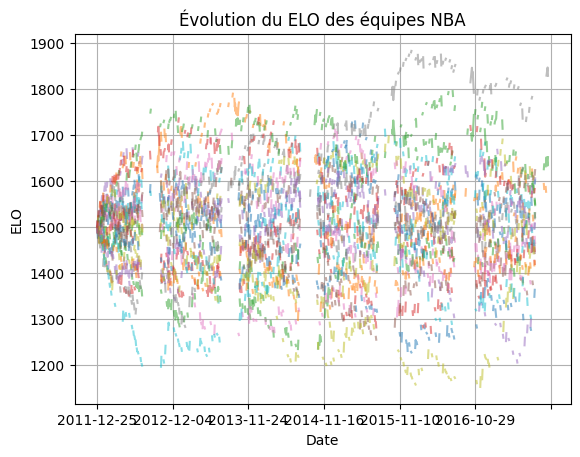

<Figure size 1.6e+06x5000 with 0 Axes>

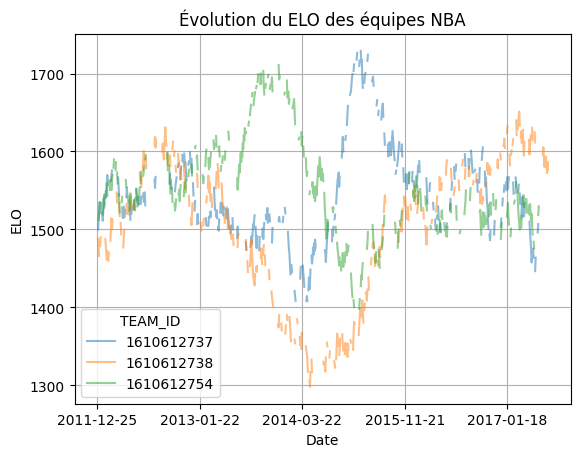

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

final_dataset_file = get_latest_file(DATA_FINAL_CLEANED_DATASET_DIR)

df = pd.read_csv(final_dataset_file)

#filter df for the last 3 seasons
df['SEASON'] = df['GAME_DATE'].str[:4].astype(int)
df = df[df['SEASON'] >= 2005]
# Convertir la colonne GAME_DATE en datetime


# Filtrer les colonnes pertinentes
elo_df = df[["GAME_DATE", "TEAM_ID", "ELO_PRE"]].dropna()

# Pivot pour mettre les équipes en colonnes
pivot_elo = elo_df.pivot_table(index="GAME_DATE", columns="TEAM_ID", values="ELO_PRE")

# Tracer l'évolution du ELO
plt.figure(figsize=(16000, 50))
pivot_elo.plot(legend=False, alpha=0.5)
plt.title("Évolution du ELO des équipes NBA")
plt.xlabel("Date")
plt.ylabel("ELO")
plt.grid(True)
plt.show()


#plot some teams
team_ids = [1610612737, 1610612738,1610612754]

# Filter the DataFrame for the selected teams
filtered_df = df[df['TEAM_ID'].isin(team_ids)]
# Create a pivot table for the selected teams
pivot_elo = filtered_df.pivot_table(index="GAME_DATE", columns="TEAM_ID", values="ELO_PRE")
# Plot the ELO for the selected teams
plt.figure(figsize=(16000, 50))
pivot_elo.plot(legend=True, alpha=0.5)
plt.title("Évolution du ELO des équipes NBA")
plt.xlabel("Date")
plt.ylabel("ELO")
plt.grid(True)
plt.show()





## 2. Heatmap de corrélation (on filtre un peu pour pas exploser la RAM)

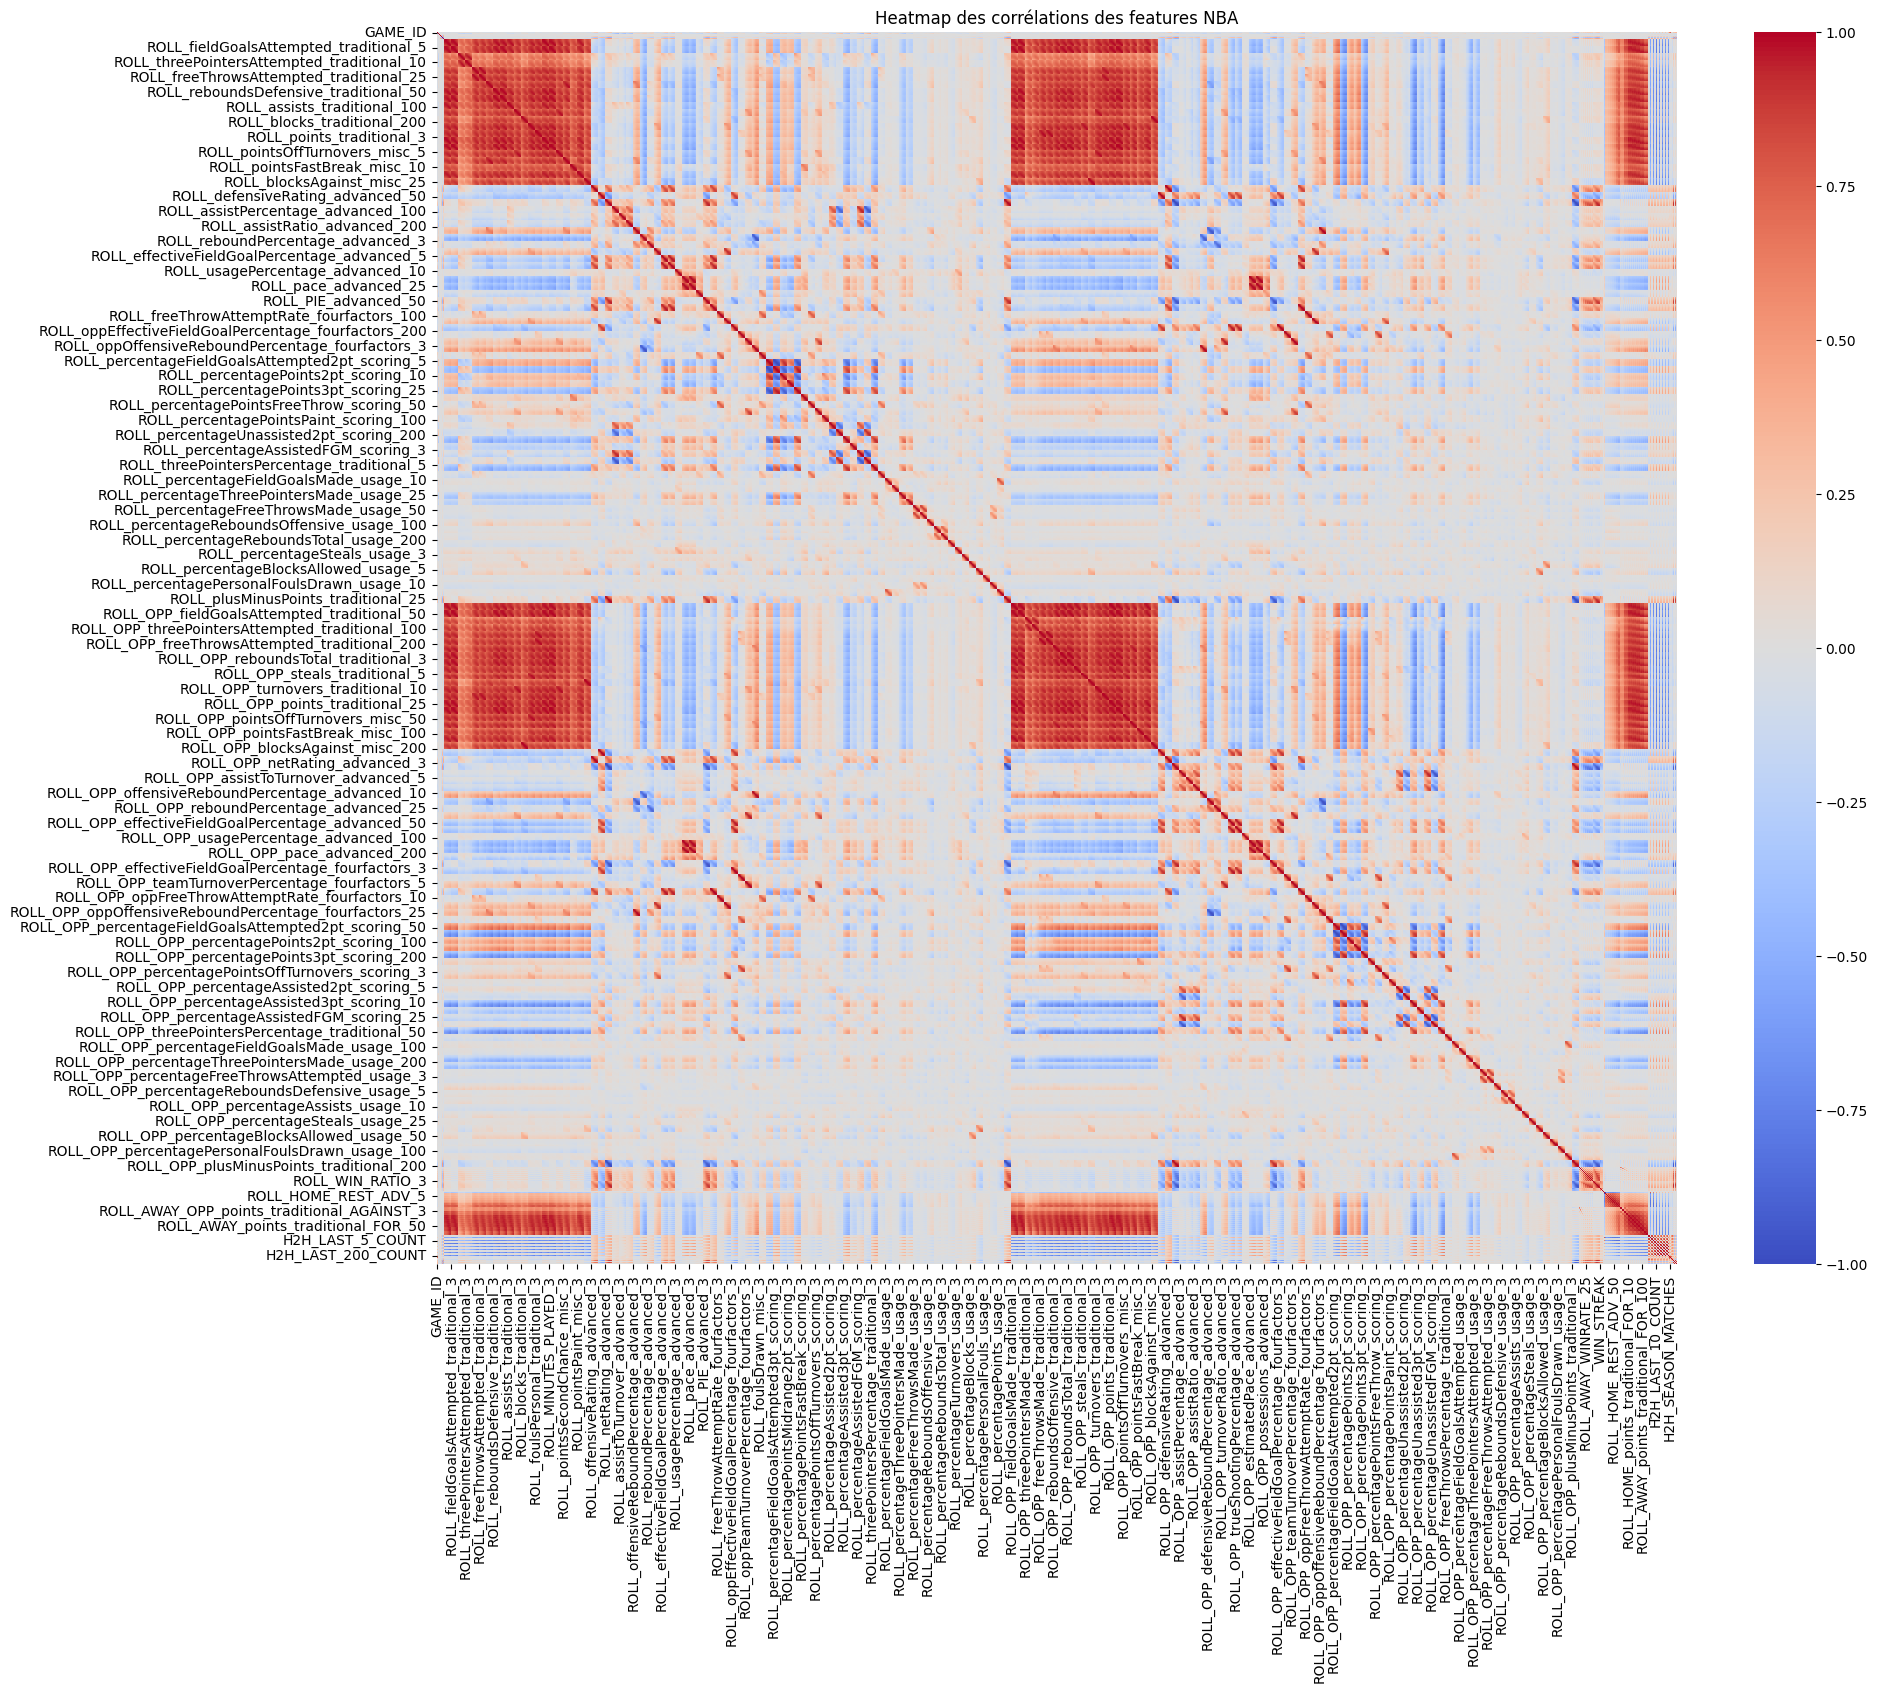

In [6]:
num_cols = [c for c in dataset.columns if dataset[c].dtype in [np.float64, np.int64, np.float32, np.int32]]
num_cols = [c for c in num_cols if c != 'IS_WIN']  # on exclut la target
corr = dataset[num_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap='coolwarm', annot=False, vmin=-1, vmax=1)
plt.title("Heatmap des corrélations des features NBA")
plt.show()

## 3. Distribution de features par win/lose

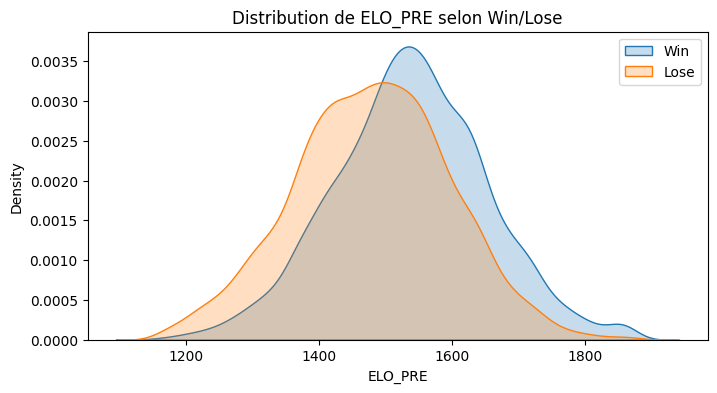

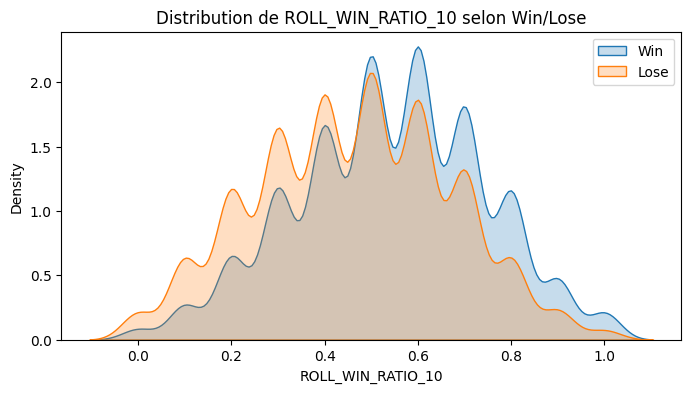

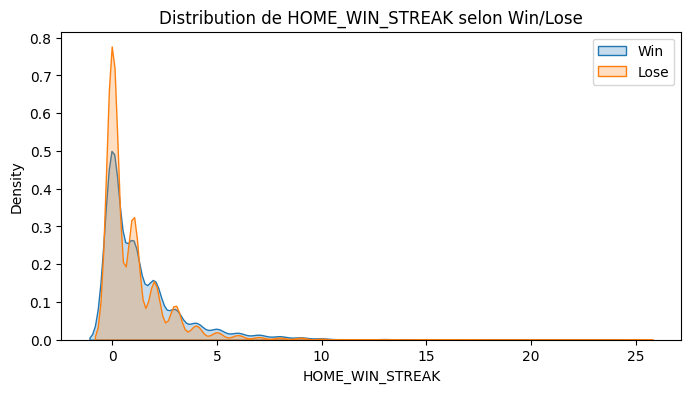

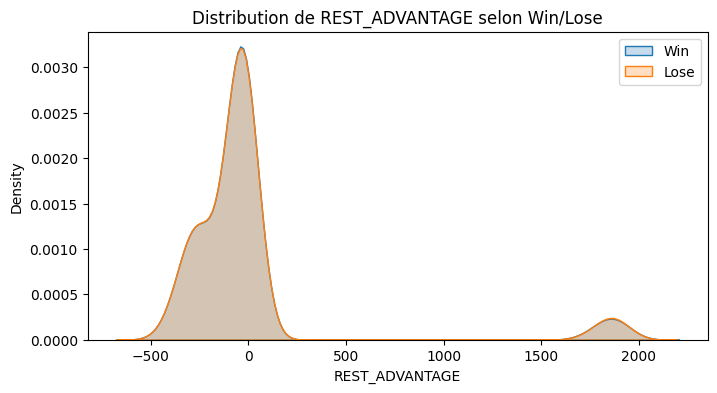

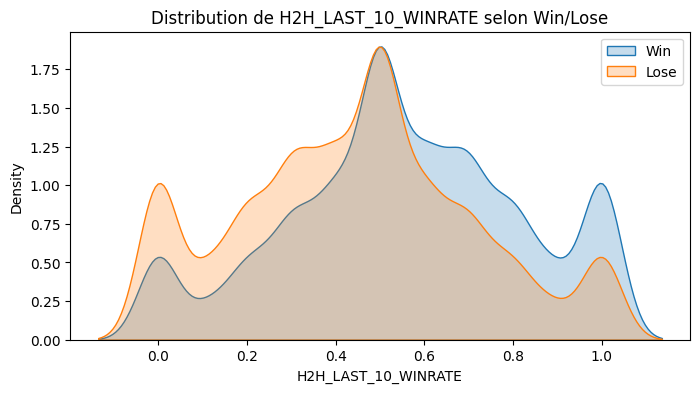

In [7]:
features_to_plot = [
    'ELO_PRE',
    'ROLL_WIN_RATIO_10',
    'HOME_WIN_STREAK',
    'REST_ADVANTAGE',
    'H2H_LAST_10_WINRATE'
]

for feat in features_to_plot:
    if feat in dataset.columns:
        plt.figure(figsize=(8, 4))
        sns.kdeplot(dataset[feat][dataset['IS_WIN'] == 1].dropna(), label='Win', fill=True)
        sns.kdeplot(dataset[feat][dataset['IS_WIN'] == 0].dropna(), label='Lose', fill=True)
        plt.title(f'Distribution de {feat} selon Win/Lose')
        plt.legend()
        plt.show()


## Split train/test

In [8]:
from sklearn.model_selection import train_test_split

# On prend toutes les colonnes numériques sauf la target
target = 'IS_WIN'
drop_cols = COLS_TO_DROP_TARGET_IS_WIN + COLS_ODDS # À adapter selon ce que tu veux/veux pas inclure
features = [col for col in dataset.columns if col not in [target] + drop_cols]

#drop na cols
dataset = dataset.dropna(subset=features)

X = dataset[features]
y = dataset[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)
print(X_train.shape, X_test.shape)


(12164, 1233) (3042, 1233)


# TEST clean des features trop corrélée

In [9]:
# import pandas as pd

# # Définis un seuil de corrélation à partir duquel tu veux supprimer
# correlation_threshold = 0.95

# # Calcule la matrice de corrélation sur les features numériques
# corr_matrix = X_train.corr().abs()

# # Sélectionne la moitié supérieure de la matrice (évite doublons symétriques)
# upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# # Trouve les colonnes à dropper
# to_drop = [column for column in upper.columns if any(upper[column] > correlation_threshold)]

# print(f"{len(to_drop)} features supprimées pour corrélation > {correlation_threshold}")
# X_train = X_train.drop(columns=to_drop)
# X_test = X_test.drop(columns=to_drop)


In [10]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Recalcule la matrice de corrélation après suppression
# corr_matrix_cleaned = X_train.corr()

# # Affiche la heatmap
# plt.figure(figsize=(18, 12))
# sns.heatmap(corr_matrix_cleaned, cmap='coolwarm', center=0, linewidths=0.5)
# plt.title("Heatmap des corrélations après suppression des features corrélées", fontsize=16)
# plt.tight_layout()
# plt.show()


## Premier modèle : Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score





clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

         0.0       0.62      0.62      0.62      1539
         1.0       0.61      0.62      0.62      1503

    accuracy                           0.62      3042
   macro avg       0.62      0.62      0.62      3042
weighted avg       0.62      0.62      0.62      3042

ROC AUC: 0.6616316857296886


###  Importance des features


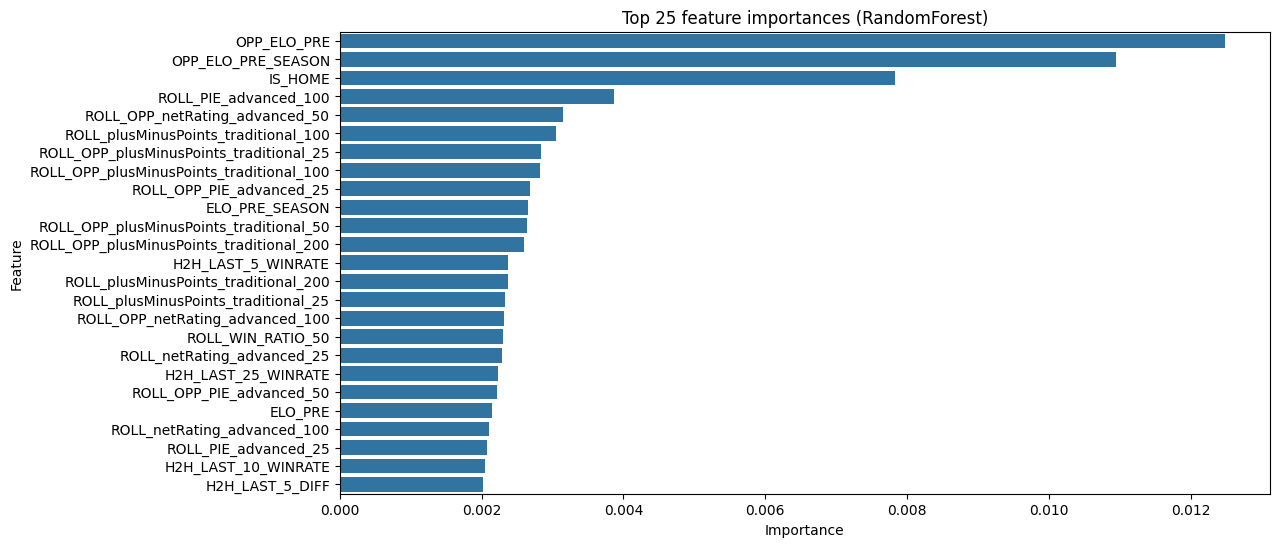

In [12]:
importances = clf.feature_importances_
feature_names = X_train.columns
importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importances_df = importances_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=importances_df.head(25))
plt.title("Top 25 feature importances (RandomForest)")
plt.show()


## Alternative : LightGBM

In [13]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


[LightGBM] [Info] Number of positive: 6097, number of negative: 6067
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.248440 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 305133
[LightGBM] [Info] Number of data points in the train set: 12164, number of used features: 1233
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501233 -> initscore=0.004933
[LightGBM] [Info] Start training from score 0.004933
              precision    recall  f1-score   support

         0.0       0.65      0.63      0.64      1539
         1.0       0.63      0.65      0.64      1503

    accuracy                           0.64      3042
   macro avg       0.64      0.64      0.64      3042
weighted avg       0.64      0.64      0.64      3042

ROC AUC: 0.7046867927562678


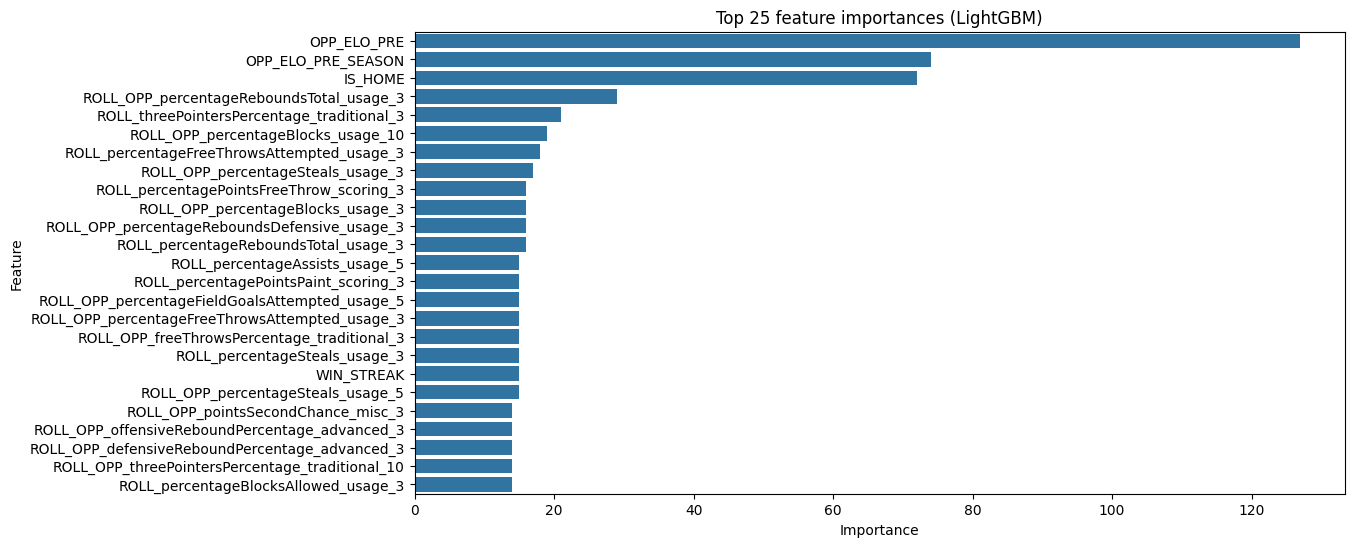

In [14]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(n_estimators=200, random_state=42)
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)
y_proba = lgbm.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))

# Feature importance
importances = lgbm.feature_importances_
importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importances_df = importances_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=importances_df.head(25))
plt.title("Top 25 feature importances (LightGBM)")
plt.show()


## Alternative XGBoost 

In [15]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
preds = xgb.predict(X_test)
probas = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probas))


e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:19:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         0.0       0.65      0.64      0.64      1539
         1.0       0.64      0.65      0.64      1503

    accuracy                           0.64      3042
   macro avg       0.64      0.64      0.64      3042
weighted avg       0.64      0.64      0.64      3042

ROC AUC: 0.7043645003689826


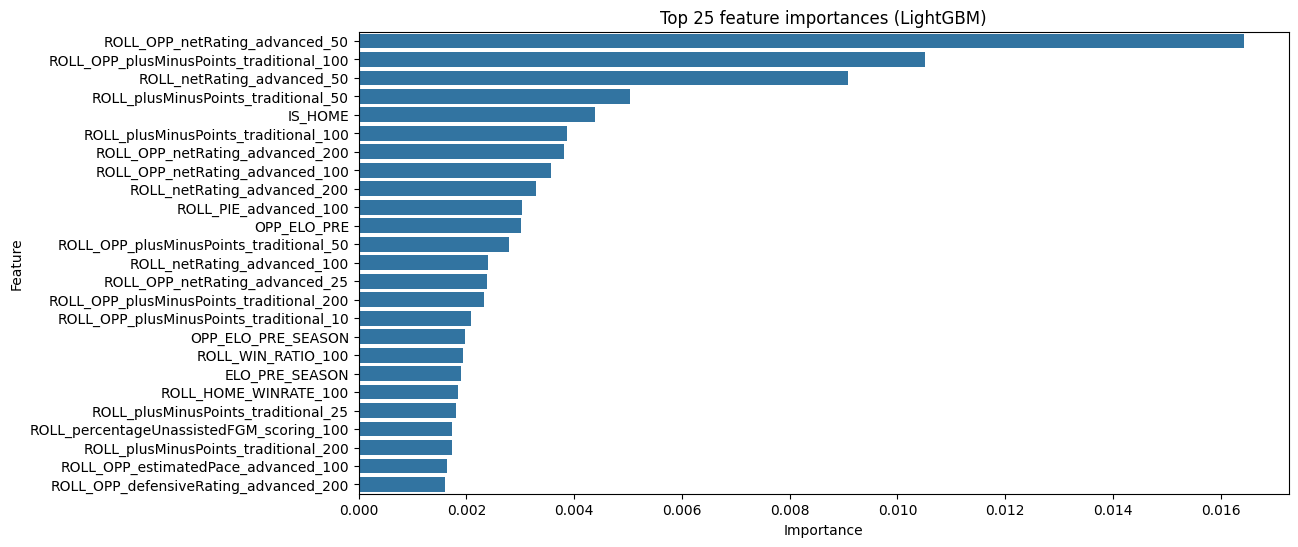

In [17]:
# Feature importance
importances = xgb.feature_importances_
importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importances_df = importances_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=importances_df.head(25))
plt.title("Top 25 feature importances (LightGBM)")
plt.show()


## Cross-Validation Chronologique (TimeSeriesSplit)
Au lieu d’un simple split train/test, fais une vraie cross-validation temporelle :

In [18]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(xgb, X, y, cv=tscv, scoring='roc_auc')
print("TimeSeries CV ROC AUC:", scores.mean())


e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:20:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:20:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:21:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:21:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "

TimeSeries CV ROC AUC: 0.7010883524005173


## Test CatBoost

In [19]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [20]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)
cat.fit(X_train, y_train)
preds = cat.predict(X_test)
probas = cat.predict_proba(X_test)[:, 1]
print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probas))


              precision    recall  f1-score   support

         0.0       0.66      0.66      0.66      1539
         1.0       0.65      0.65      0.65      1503

    accuracy                           0.65      3042
   macro avg       0.65      0.65      0.65      3042
weighted avg       0.65      0.65      0.65      3042

ROC AUC: 0.7222384341129306


## Calibration des probabilités

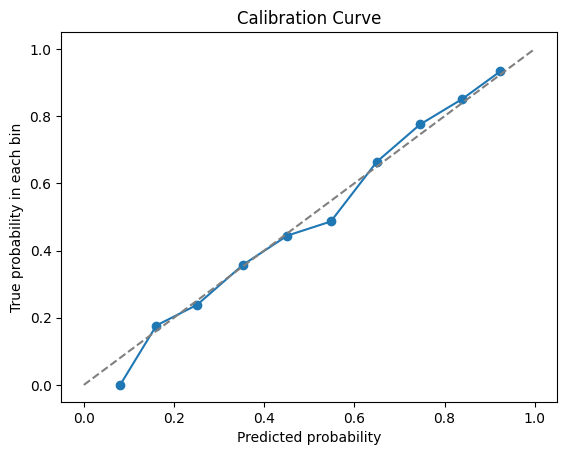

In [21]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, probas, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('Predicted probability')
plt.ylabel('True probability in each bin')
plt.title('Calibration Curve')
plt.show()


## SHAP Values pour l’interprétabilité

In [22]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


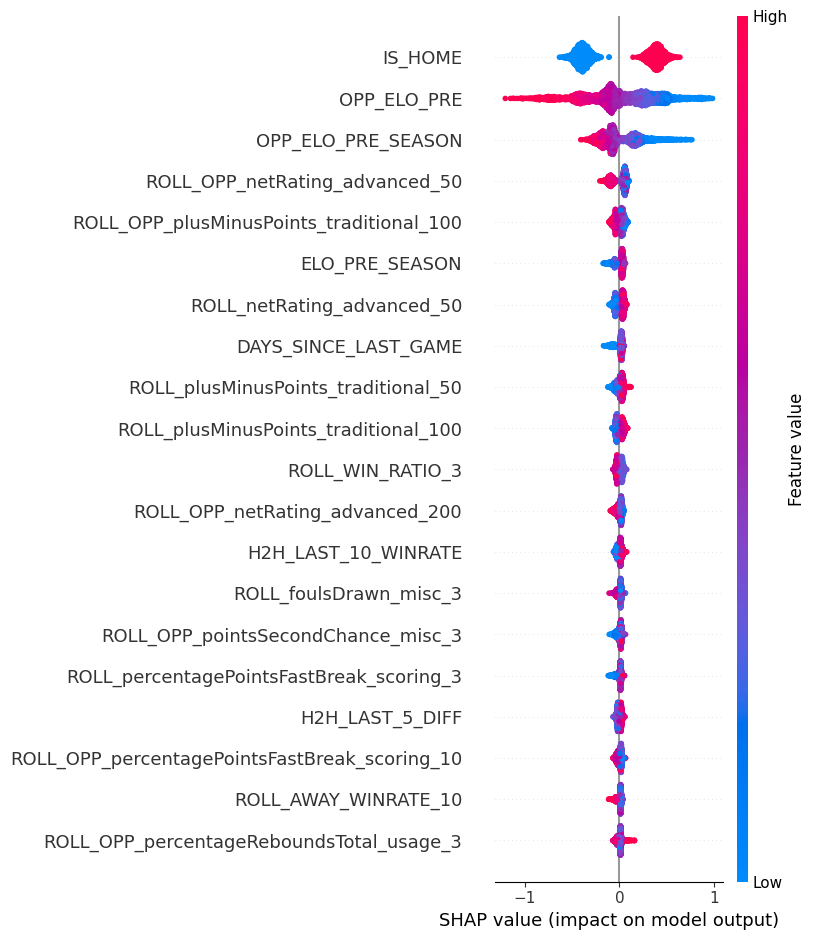

In [23]:
import shap
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)


## Permutation importance

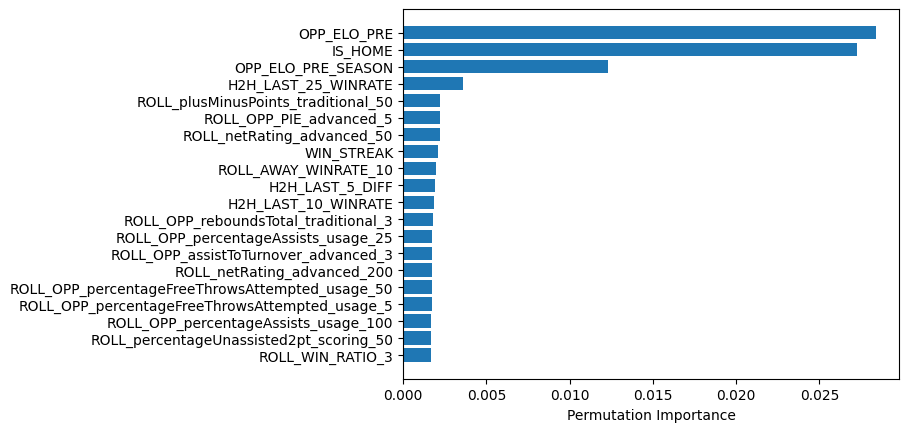

In [24]:
from sklearn.inspection import permutation_importance
result = permutation_importance(xgb, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()[-20:]
plt.barh(np.array(X_test.columns)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.show()


e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:50:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:51:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:51:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:52:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "

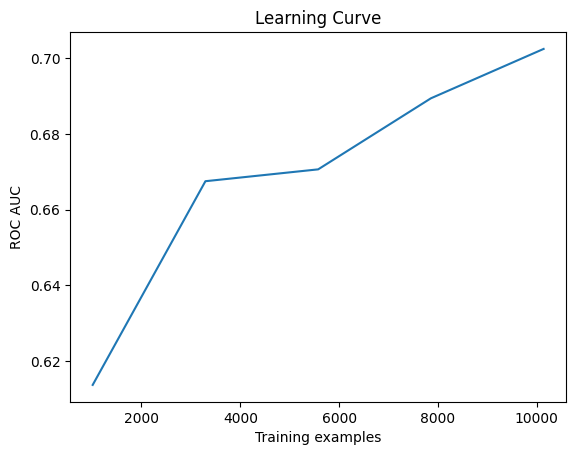

In [25]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(xgb, X, y, cv=3, scoring='roc_auc')
plt.plot(train_sizes, test_scores.mean(axis=1))
plt.title('Learning Curve')
plt.xlabel('Training examples')
plt.ylabel('ROC AUC')
plt.show()


# Stacking des modeles (lourd)

In [ ]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Sépare ton X/y normalement (ou récupère ton split habituel)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Définis tes modèles de base
estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ('lgbm', LGBMClassifier(n_estimators=150, num_leaves=64, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, subsample=0.7, colsample_bytree=0.7, random_state=42, eval_metric='logloss', n_jobs=-1, use_label_encoder=False)),
    ('cat', CatBoostClassifier(n_estimators=200, learning_rate=0.05, depth=6, rsm=0.8, verbose=0, random_state=42)),
    ('hgb', HistGradientBoostingClassifier(max_iter=200, random_state=42)),
    ('lr', make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, solver='liblinear', penalty='l2'))),
    ('mlp', make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42))),
    ('et', ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15, n_jobs=-1)))
]

# Meta-model (peut être LogisticRegression, simple et efficace)
meta_model = LogisticRegression(solver='lbfgs', max_iter=5000)

# Création du stacking
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    passthrough=True,
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fit le stacking
stack.fit(X_train, y_train)

# Prédictions
y_pred = stack.predict(X_test)
y_proba = stack.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


In [ ]:
#store start time of notebook
start_time = datetime.datetime.now()
print("Start time: ", start_time)

Start time:  2025-06-05 04:35:25.586929
